# Cleaning Data (IDN Version)
Plan:
1. Melakukan pengecekan dataset (Apa yang missing, duplikat, ID unik, dll)
2. Analisa dataset (EDA, visualisasi data)
3. Pengambilan Keputusan
4. Eksekusi 

- Plan ini bisa berubah, tergantung kondisi

## Persiapan Library

In [2]:
# Library yang dibutuhkan

import pandas as pd # untuk manipulasi data
import numpy as np # untuk operasi matematika
import matplotlib.pyplot as plt # untuk visualisasi data
import seaborn as sns # untuk visualisasi data yang lebih menarik

## Persiapan dan Pengecekan Dataset
---
Jadi ya gitu wkwkw

In [3]:
# Membaca dataset
train = "../raw/train.csv"
test = "../raw/test.csv"
sub = "../raw/gender_submission.csv" # Untuk nanti

train_df = pd.read_csv(train) # Fokus ke data train dulu
test_df = pd.read_csv(test)
sub_df = pd.read_csv(sub)

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Check distribusi data train

print("===== Distribusi data =====")
print(train_df['Survived'].value_counts())

print("\nSelisih antara 0 dan 1:",
      train_df['Survived'].value_counts()[0] - train_df['Survived'].value_counts()[1])

===== Distribusi data =====
Survived
0    549
1    342
Name: count, dtype: int64

Selisih antara 0 dan 1: 207


In [5]:
# Check missing values

print("===== Missing Values =====")

missing_percentage = (
    train_df.isnull().sum() / len(train_df) * 100
).round(1)

missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

===== Missing Values =====


Cabin       77.1
Age         19.9
Embarked     0.2
dtype: float64

In [6]:
# Check data
print("===== Data Info =====")
train_df.info()

===== Data Info =====
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# Check data duplikasi
print("===== Data Types =====")
train_df.duplicated().sum()

===== Data Types =====


np.int64(0)

In [8]:
# Checck data shape

print("===== Data Shape =====")
print("Train data shape:", train_df.shape)

===== Data Shape =====
Train data shape: (891, 12)


### REKAPITULASI STEP I
---
- Adanya missing data pada kolom "age", "cabin" dan "Embarked" (hanya 2 missing)
- Selisih label survival dengan tidak yaitu 207 baris
- Perlu menganalisa dataset lebih spesifik
- Ini untuk saat ini (Wednesday, 18 June 2026)

## Analisa Dataset (EDA)
---
<b>Mari kita lihat data secara visual dan data statistik</b>
<br>
Plan : 
1. Melihat distribusi masing-masing kolom
2. Visualisasi data
3. Menampilkan data statistik
4. Melihat korelasi masing-masing fitur pada label
5. Interpretasi

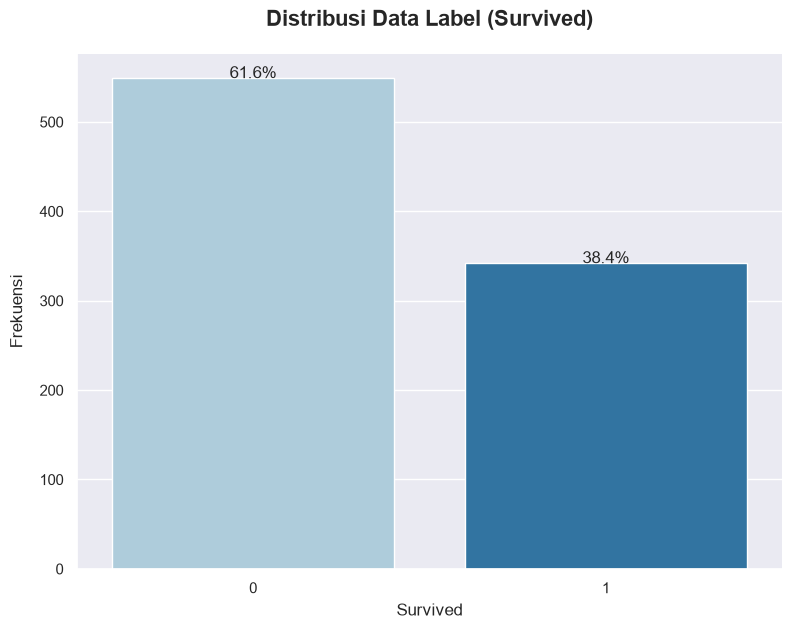

In [9]:
# Check distribusi data label menggunakan matplotlib dan seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    x="Survived",
    data=train_df,
    palette="Paired",
    hue="Survived",
    legend=False
)

total = len(train_df)

for p in ax.patches:
    count=p.get_height()

    percentage = 100 * count / total

    ax.annotate(
        f'{percentage:.1f}%',
        (
            p.get_x() + p.get_width()/2,
            count
        ),
        ha='center'
    )

# Untuk menampilkan frekuensi data pada setiap bar
sns.despine()

plt.tight_layout()
plt.title(
    "Distribusi Data Label (Survived)",
    fontsize=16,
    fontweight="bold",
    pad=20
    )
plt.xlabel("Survived", labelpad=5)
plt.ylabel("Frekuensi", labelpad=10)

plt.show()

### <h3><b>INTERPRETASI DARI VISUALISASI DISTRIBUSI LABEL</b></h3>
<p style= "text-align: justify;">
Berdasarkan visualisasi ditribusi di atas, kelas 0 memiliki proporsi data sebesar 61.6%, sedangkan kelas 1 memiliki proporsi sebesar 38.4%.
Meskipun kelas 0 mendominasi kelas 1, bisa dikatakan <b>bahwa perbandingan kedua kelas cukup seimbang dan tidak menunjukkan adanya class imbalance
yang ekstrem</b>. Oleh karena itu, diperkirakan ketidakseimbangan class tidak menjadi masalah utama dalam pelatihan model.
</p>

<h4>
Pertanyaan:
</h4>

---
- Apa saja yang mungkin mempengaruhi tingkat keselamatan penumpang? (Berhipostesi dulu) <br>

Menurutku secara intuisi dan penalaran induktif: <br>
1. Pclass -> akan berkolerasi dengan cabin yang digunakan dan kelompok sosial (Lu ada duit, lu ada kuasa :D)
2. Cabin -> Entahlah... 
3. Embarked -> KEmungkinan jika penumpang telat memasuki kapal, dia selamat :P
4. Sex -> Berpengaruh dari segi bertahan hidup karena fisik pria bisa dikatakan lebih tahan banting <br><br>
... ini hipotesisku untuk saat ini. (Akan diperbarui sepanjang melakukan analisa)


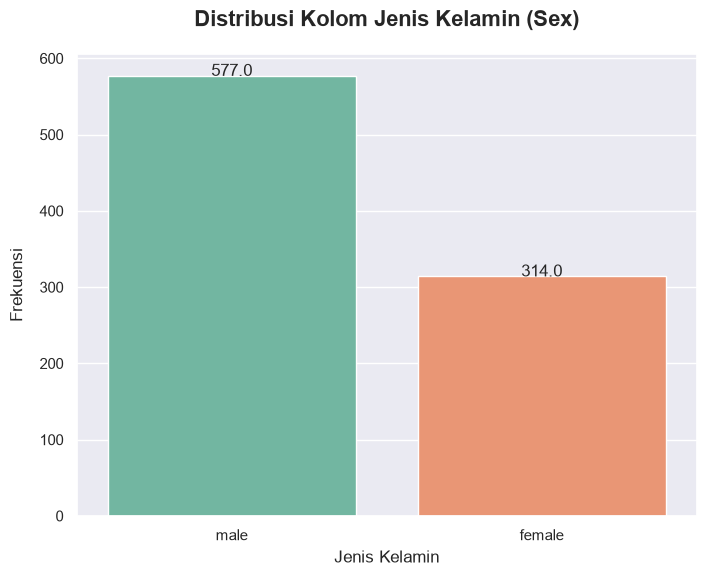

In [26]:
# Check distribusi kolom sex dengan diagram batang

sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=train_df,
    x="Sex",
    hue="Sex",
    palette="Set2",
    legend=False
)

total = len(train_df)
for p in ax.patches:
    count=p.get_height()


    ax.annotate(
        f'{count}',
        (
            p.get_x() + p.get_width()/2,
            count
        ),
        ha='center'
    )

plt.title(
    "Distribusi Kolom Jenis Kelamin (Sex)",
    fontsize=16,
    fontweight="bold",
    pad=20
    )
plt.xlabel("Jenis Kelamin", labelpad=5)
plt.ylabel("Frekuensi", labelpad=10)
plt.show()

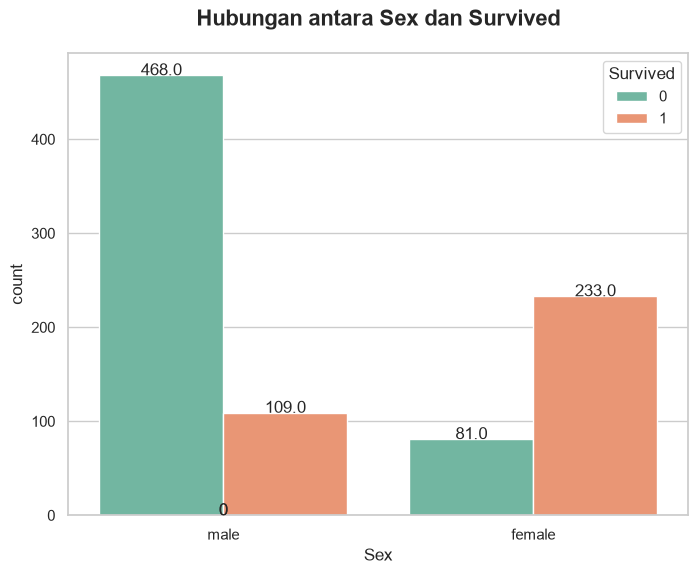

In [25]:
# Check hipotesis dengan visualisasi data
# ================================================================

# Visualisasi hubungan antara jenis kelamin dan kelangsungan hidup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=train_df,
    x="Sex",
    hue="Survived",
    palette="Set2",
    legend=True
)

for p in ax.patches:
    count=p.get_height()

    ax.annotate(
        f'{count}',
        (
            p.get_x() + p.get_width()/2,
            count
        ),
        ha='center'
    )
ax.set_title(
    "Hubungan antara Sex dan Survived",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.show()

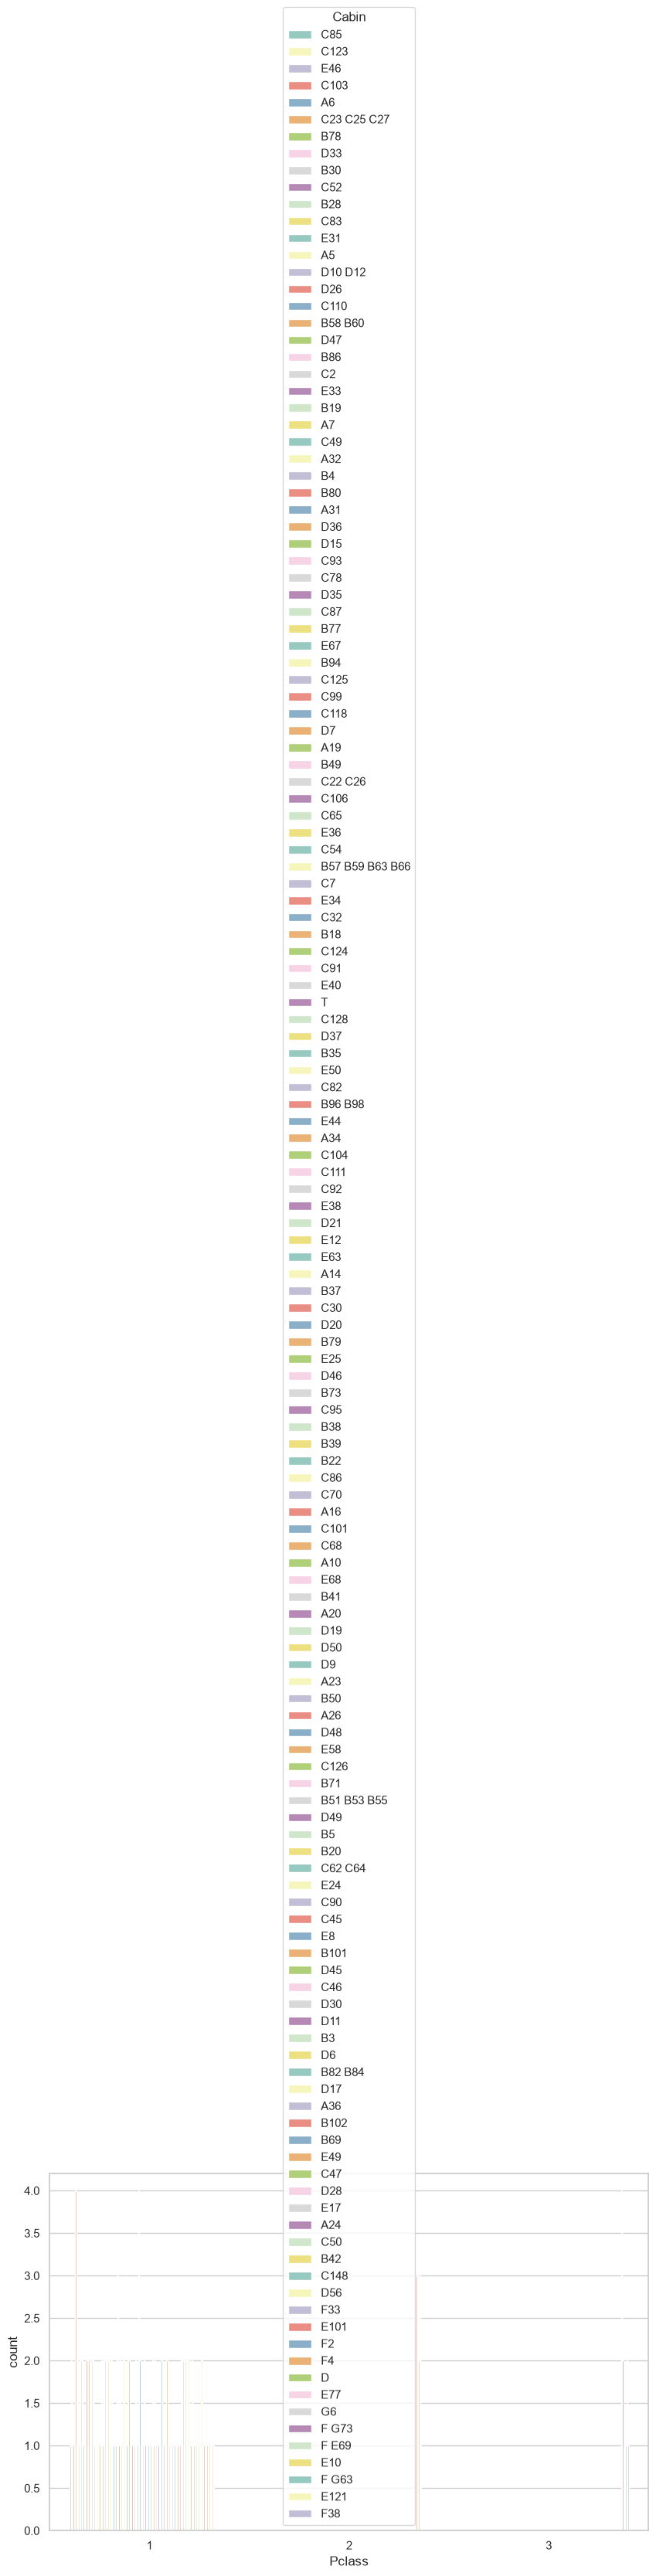

In [ ]:
# Check hubungan antara Pclass dengan Cabin

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.countplot(
    data=train_df,
    x="Pclass",
    hue="Cabin",
    palette="Set3",
    legend=True,
)

plt.show()

# Note: Manipulasi data dengan menjadi 1 untuk memiliki kabin dan 0 untuk tidak memiliki kabin

In [11]:
#=======================================================================================================================================================

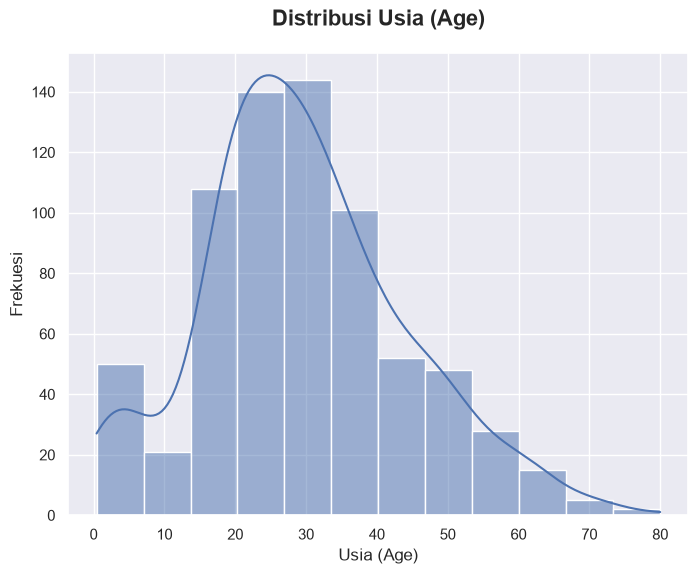

In [12]:
# Check data numberik "age" secara histogram
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))

sns.histplot(
    data=train_df,
    x="Age",
    bins=12,
    kde=True,
)

plt.title(
    "Distribusi Usia (Age)",
    fontsize=16,
    fontweight="bold",
    pad=20
    )
plt.xlabel("Usia (Age)")
plt.ylabel("Frekuesi")

plt.show()

### <h3><b>INTERPRETASI DARI VISUALISASI DISTRIBUSI AGE</b></h3>
<p style= "text-align: justify;">
Berdasarkan visualisasi di atas, diketahui bentuk histogram membentuk kurva loceng ke arah kiri dengan distribusi data dominan pada rentang 20 - 35. Lalu ada data yang outlier pada rentang 0 - 5. Disimpulkan bahwa <b>jumlah penumpang kapal titanic dominan dalam rentang umur 20 - 35 tahun</b>, dan seperti pada step pertama adanya missing value pada kolom Age sebesar ~20%, sehingga mungkin mempengaruhi jumlah rentang pada nilai 0 - 5.
</p>

---
- Bagaimana rentang penumpang yang selamat berdasarkan umur?<br>
Hypotesis: Kemungkinan pada rentang dominan karena diketahui bahwa umur 20 - 35 bisa dikatakan masih fit dan sehat

- Apakah umur mempengaruhi tingkat keselamatan penumpang?<br>
Hypotesis: Bisa jadi, tapi dengan tingkat korelasi rendah, karena diketahui bahwa jatuhnya kapal titanic ada pada laut dalam dan dingin (Dapet dari movie)



In [13]:
#=======================================================================================================================================================

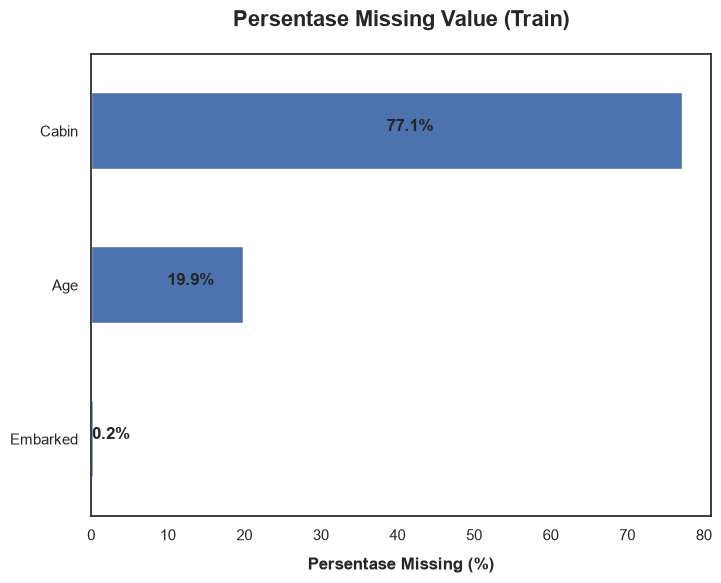

In [14]:
# Check apakah ada data yang missing pada dataset

sns.set_theme(style="white")
plt.figure(figsize=(8, 6))

missing_percentage = (
    train_df.isnull().sum() / len(train_df) * 100
) # Mengambil persentase missing value

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values()

ax = missing_percentage.plot.barh()

for p in ax.patches:
    percentage = p.get_width()
    count = p.get_y() + p.get_height()/2
    ax.annotate(
        f'{percentage:.1f}%',
        (
            p.get_x() + p.get_width()/2,
            count
        ),
        fontweight='bold'
    )

plt.xlabel(
    "Persentase Missing (%)",
    fontweight="bold",
    labelpad=10
    )
plt.title("Persentase Missing Value (Train)", fontsize=16, fontweight="bold", pad=20)
plt.show()

### <h3><b>INTERPRETASI DARI VISUALISASI MISSING VALUE</b></h3>
<p style= "text-align: justify;">
Berdasarkan visualisasi missing value, diketahui bahwa persentase terbesar yaitu Cabin dengan nilai ~77.1% (Dengan 23.9% yang memiliki value), dibandingkan dengan kolom age (19.9%) dan Embarked (0.2%). Kemungkinan besarnya persentase missing value pada "Cabin" bisa menyebabkan bias yang tinggi dalam pelatihan model, begitu juga dengan Age. Meskipun Embarked memiliki missing value yang sangat sedikit, kemungkinan tidak akan mempengaruhi akurasi dalam pelatihan model.
</p>

---
- Mengapa bisa menyebabkan terjadinya missing value pada masing-masing value?<br><br>
Hypotesis: 
1. Cabin -- Dikarenakan pclass first class memiliki cabin sendiri. Sehingga penumpang lain dengan pclass bawah (2, 3) tida memiliki cabin.
2. Age -- Dikarenakan penumpang tidak mengetahui umurnya sendiri :P.
3. Embarked -- Dikarenakan penumpang ada yang telat memasuki kapal sehingga tidak dicatat di pelabuhan, sehingga membuat penumpang selamat.
